## Importing library

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

## Loading dataset - display first 10 rows

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


## Shape of data

In [3]:
df.shape

(2200, 8)

- Rows: 2200
- Columns: 8

## Column Names

In [4]:
column_names=df.columns
column_names

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

## Data Types per column

In [5]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

## Description of columns

In [6]:
# description dictionary
description_dict = {
    'N': 'Soil Nitrogen Content',
    'P': 'Soil Phosphorous Content',
    'K': 'Soil Potassium Content',
    'temperature': 'Soil Average Temperature',
    'humidity': 'Soil Humidity Content',
    'ph': 'Soil ph level',
    'rainfall': 'Soil total rainfaill received',
    'label': 'Recommended Crop',

}

# data dictionary table
data_dict = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
})

# mapping decription column deom description dictionary
data_dict['Description'] = data_dict['Column Name'].map(description_dict)

In [7]:
print(data_dict)

   Column Name Data Type  Non-Null Count  Null Count  \
0            N     int64            2200           0   
1            P     int64            2200           0   
2            K     int64            2200           0   
3  temperature   float64            2200           0   
4     humidity   float64            2200           0   
5           ph   float64            2200           0   
6     rainfall   float64            2200           0   
7        label    object            2200           0   

                     Description  
0          Soil Nitrogen Content  
1       Soil Phosphorous Content  
2         Soil Potassium Content  
3       Soil Average Temperature  
4          Soil Humidity Content  
5                  Soil ph level  
6  Soil total rainfaill received  
7               Recommended Crop  


- N : This is a numerical column that quantifies the amount of Nitrogen in the soil
- P : This is a numerical column that quantifies the amount of Phosphorous in the soil
- K : This is a numerical column that quantifies the amount of Potassium in the soil
- Temperature : This is a numerical column that quantifies the temperature of the soil
- Humidity : This is a numerical column that quantifies the amount of water in the soil
- ph : This is a numerical column that quantifies the acidity of the soil
- rainfall : This is a numeric column that quantifies the total amount of rainfall had 
- label : This is a categorical column that shows the crops that can be predicted

## Checking for missing values - per column

In [8]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

there are zero missing values per column

## Exploratory Data Analysis (EDA)

## descriptive statistics for numeric features

In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## Checking for Normality

In [10]:
from scipy.stats import shapiro

for i in df.drop(columns='label'):
    stat, p = shapiro(df[i])

    print(f"{i} Statistic:", stat)
    print(f"{i} p-value:", p)

    if p > 0.05:
        print(f"{i}: Data is normally distributed")
    else:
        print(f"{i}: Data is NOT normally distributed\n")

N Statistic: 0.9153964073962355
N p-value: 2.1317863704536043e-33
N: Data is NOT normally distributed

P Statistic: 0.9111665197650068
P p-value: 4.707127807833243e-34
P: Data is NOT normally distributed

K Statistic: 0.6055315946022244
K p-value: 2.5025148097693175e-57
K: Data is NOT normally distributed

temperature Statistic: 0.9820977777366943
temperature p-value: 5.261630442031878e-16
temperature: Data is NOT normally distributed

humidity Statistic: 0.8663654491198436
humidity p-value: 8.311765373018126e-40
humidity: Data is NOT normally distributed

ph Statistic: 0.9791020405966577
ph p-value: 1.955271724312567e-17
ph: Data is NOT normally distributed

rainfall Statistic: 0.9302699041867273
rainfall p-value: 7.289020556526317e-31
rainfall: Data is NOT normally distributed



## Checking for outliers


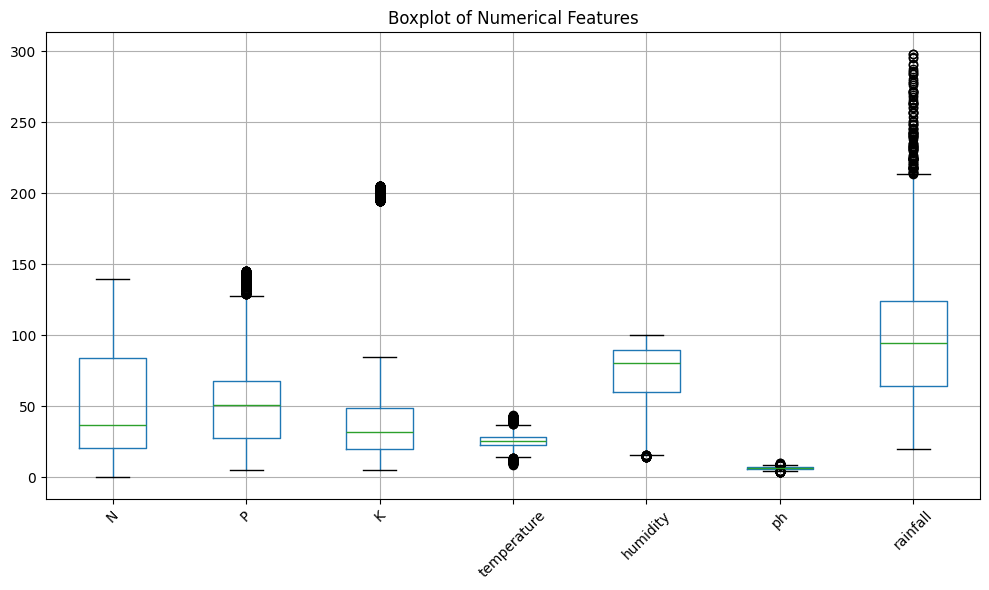

In [11]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 6))
df[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
plt.tight_layout()
plt.show()

## Removing outliers - IQR Method

In [12]:
def remove_outliers_iqr(df, columns):
    global df_clean

    df_clean = df.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
 
        
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
 
    return df_clean

In [13]:
remove_outliers_iqr(df, numeric_columns)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


- Since all my columns in the dataset are not normally distributed, we chose the IQR method since it is more robust to data that is not normally distributed

## Confirming Outliers have been removed

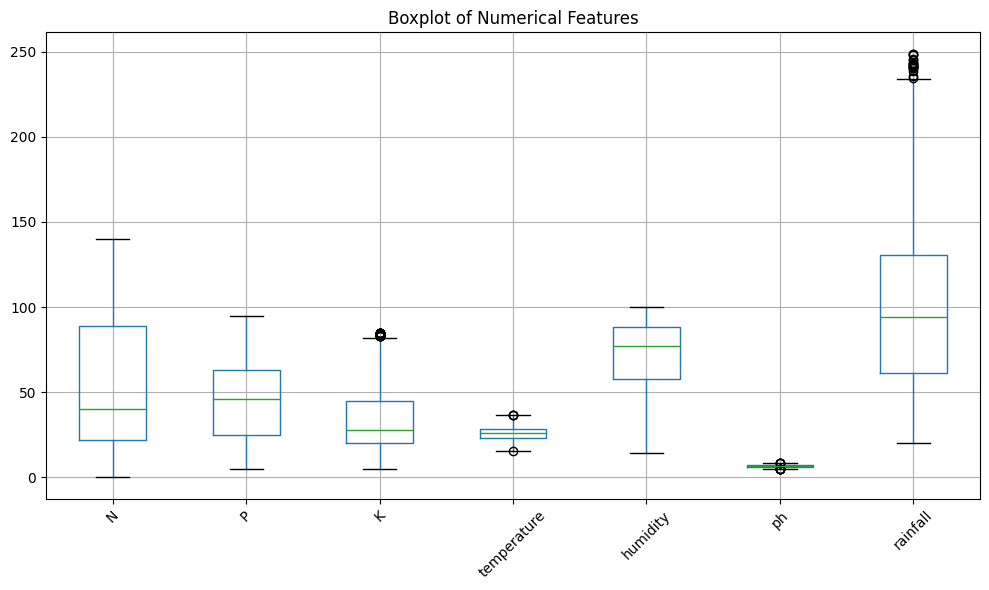

In [14]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 6))
df_clean[numeric_columns].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
plt.tight_layout()
plt.show()

# Encoding categorical variables - Label Encoding

In [15]:
df_clean['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'watermelon', 'muskmelon', 'orange', 'papaya',
       'coconut', 'cotton', 'jute', 'coffee'], dtype=object)

- Since they are 20 crops hence 20 categories, label encoding is more efficient for handling many categories other than one-hot encoding that handles for two categories only
- Label encoding ensures that our categories are not labeled with numerical importance

In [16]:
map={'rice':1,       'maize':2,    'chickpea':3, 'kidneybeans':4,  'pigeonpeas':5,
   'mothbeans':6,    'mungbean':7,   'blackgram':8,      'lentil':9, 'pomegranate':10,
      'banana':11,       'mango':12,  'watermelon':13,   'muskmelon':14,      'orange':15,
      'papaya':16,     'coconut':17,      'cotton':18,        'jute':19,      'coffee':20}

In [17]:
df_clean['label_encoded']=df_clean['label'].map(map)
df_clean['label_encoded'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [18]:
df_clean.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice,1
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice,1
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice,1
13,93,56,36,24.014976,82.056872,6.984354,185.277339,rice,1
14,94,50,37,25.665852,80.663850,6.948020,209.586971,rice,1
15,60,48,39,24.282094,80.300256,7.042299,231.086335,rice,1
17,91,35,39,23.793920,80.418180,6.970860,206.261186,rice,1


## dropping unnecessary column - `label`

In [19]:
df_clean.drop('label', axis=1, inplace=True)
df_clean

,N,P,K,temperature,humidity,ph,rainfall,label_encoded
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
7,94,53,40,20.277744,82.894086,5.718627,241.974195,1
8,89,54,38,24.515881,83.535216,6.685346,230.446236,1
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,20
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,20
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,20
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,20


## UNIVARIATE ANALYSIS

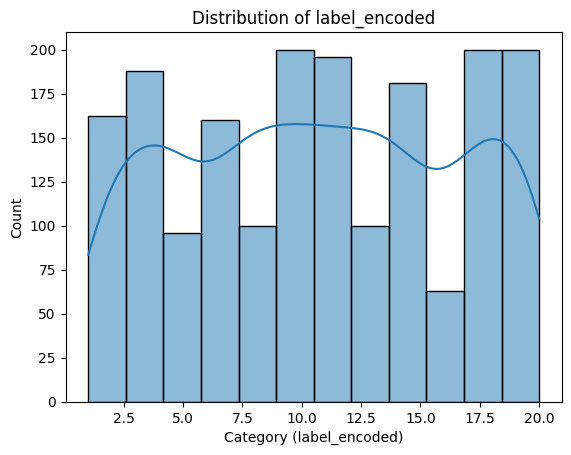

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.histplot(x=df_clean['label_encoded'], data=df_clean, kde=True)

plt.xlabel('Category (label_encoded)')
plt.ylabel('Count')
plt.title('Distribution of label_encoded')

plt.show()

- The target variable (`label_encoded`) represents 20 crop classes encoded as integers 1–20.
- The distribution is **approximately balanced**: each crop class appears roughly the same number of times (~100 samples per class), meaning the dataset is not skewed towards any particular crop.
- This balance is ideal for classification — the model will not be biased toward a majority class, and accuracy is a reliable metric.
- Since Random Forest and Decision Tree handle imbalanced and non-normally distributed data well, no class rebalancing (e.g. SMOTE) is required.

## Histogram for the distribution of numerical variables

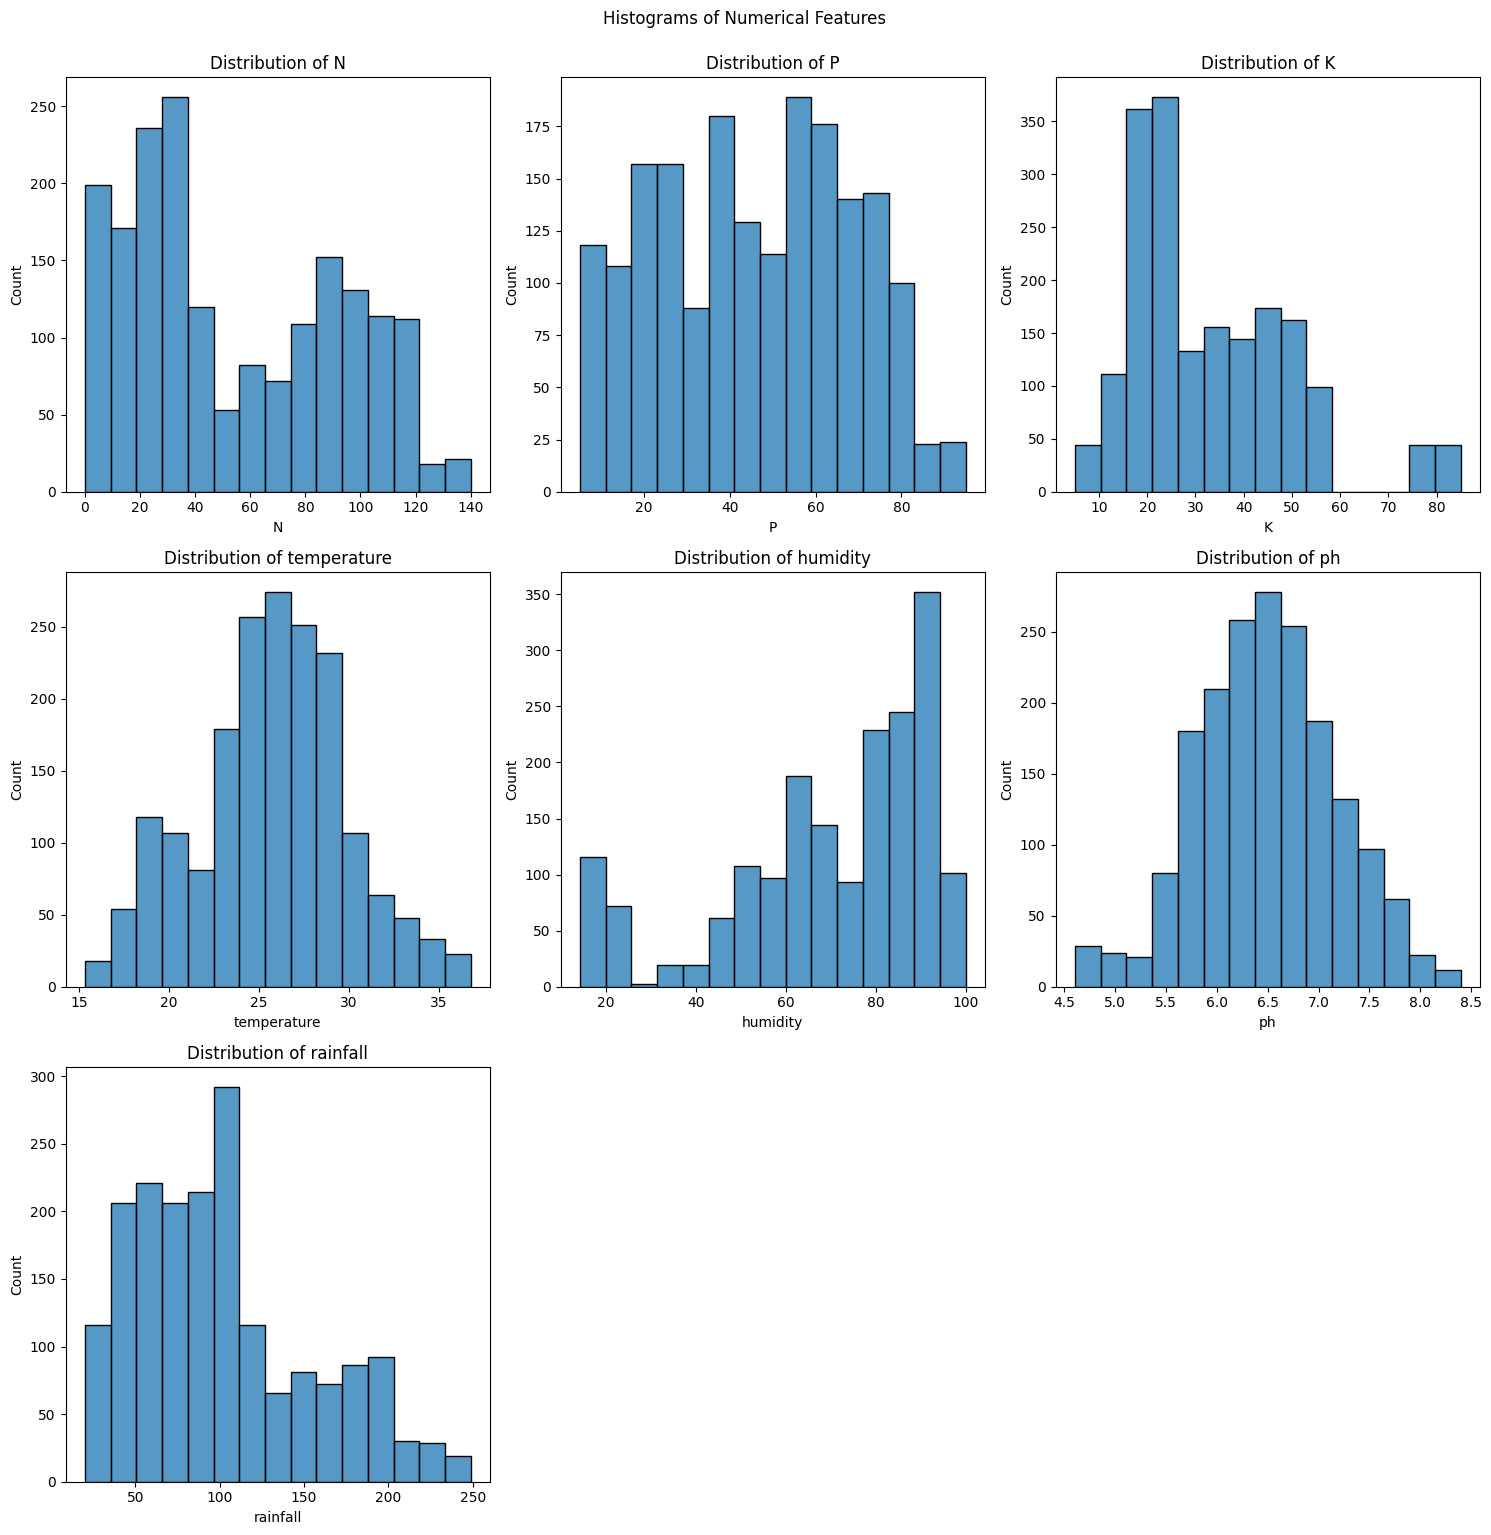

In [53]:
import seaborn as sns
import math

num_cols = numeric_columns
n = len(num_cols)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col].dropna(), bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.show()

Nitrogen: It is not normally distributed.

Phosphorous: It is not normally distributed
 
Potassium: It is not normally distributed.

Temperature: It is normally distributed.

Humidity: It is not normally distributed.

Ph : It is normally distributed.

Rainfall: It is not normally distributed.


## BIVARIATE AND MULTIVARIATE ANALYSIS

## Correlation heatmap for all numeric features

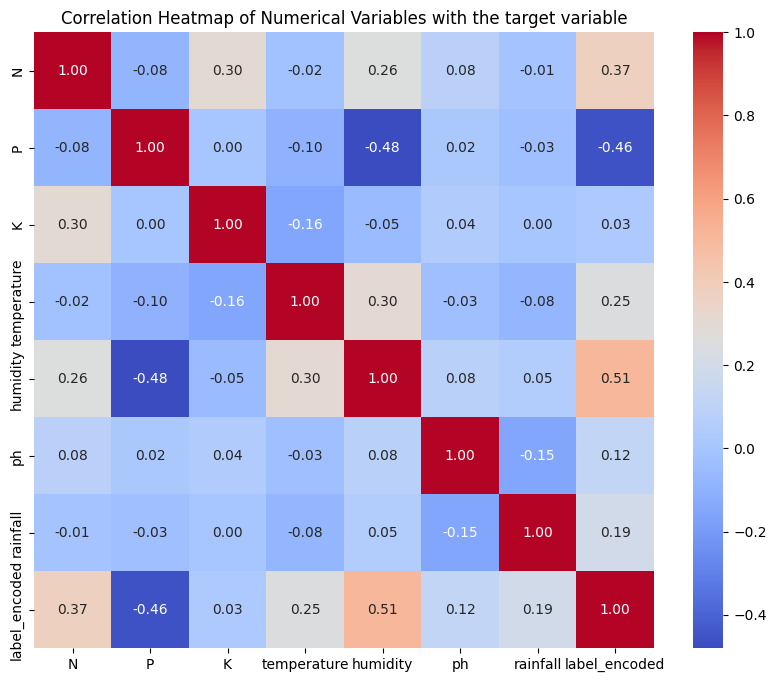

In [41]:
# numerical columns selection
num_df = df_clean.select_dtypes(include=['int64', 'float64'])

# correlation matrix
corr = num_df.corr()

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Variables with the target variable")
plt.show()

The Key features with the highest correlation with the target variable are: 

1.Humidity

2.Phosphorous 

3.Nitrogen

## Boxplots to show relationship between key features and target variable

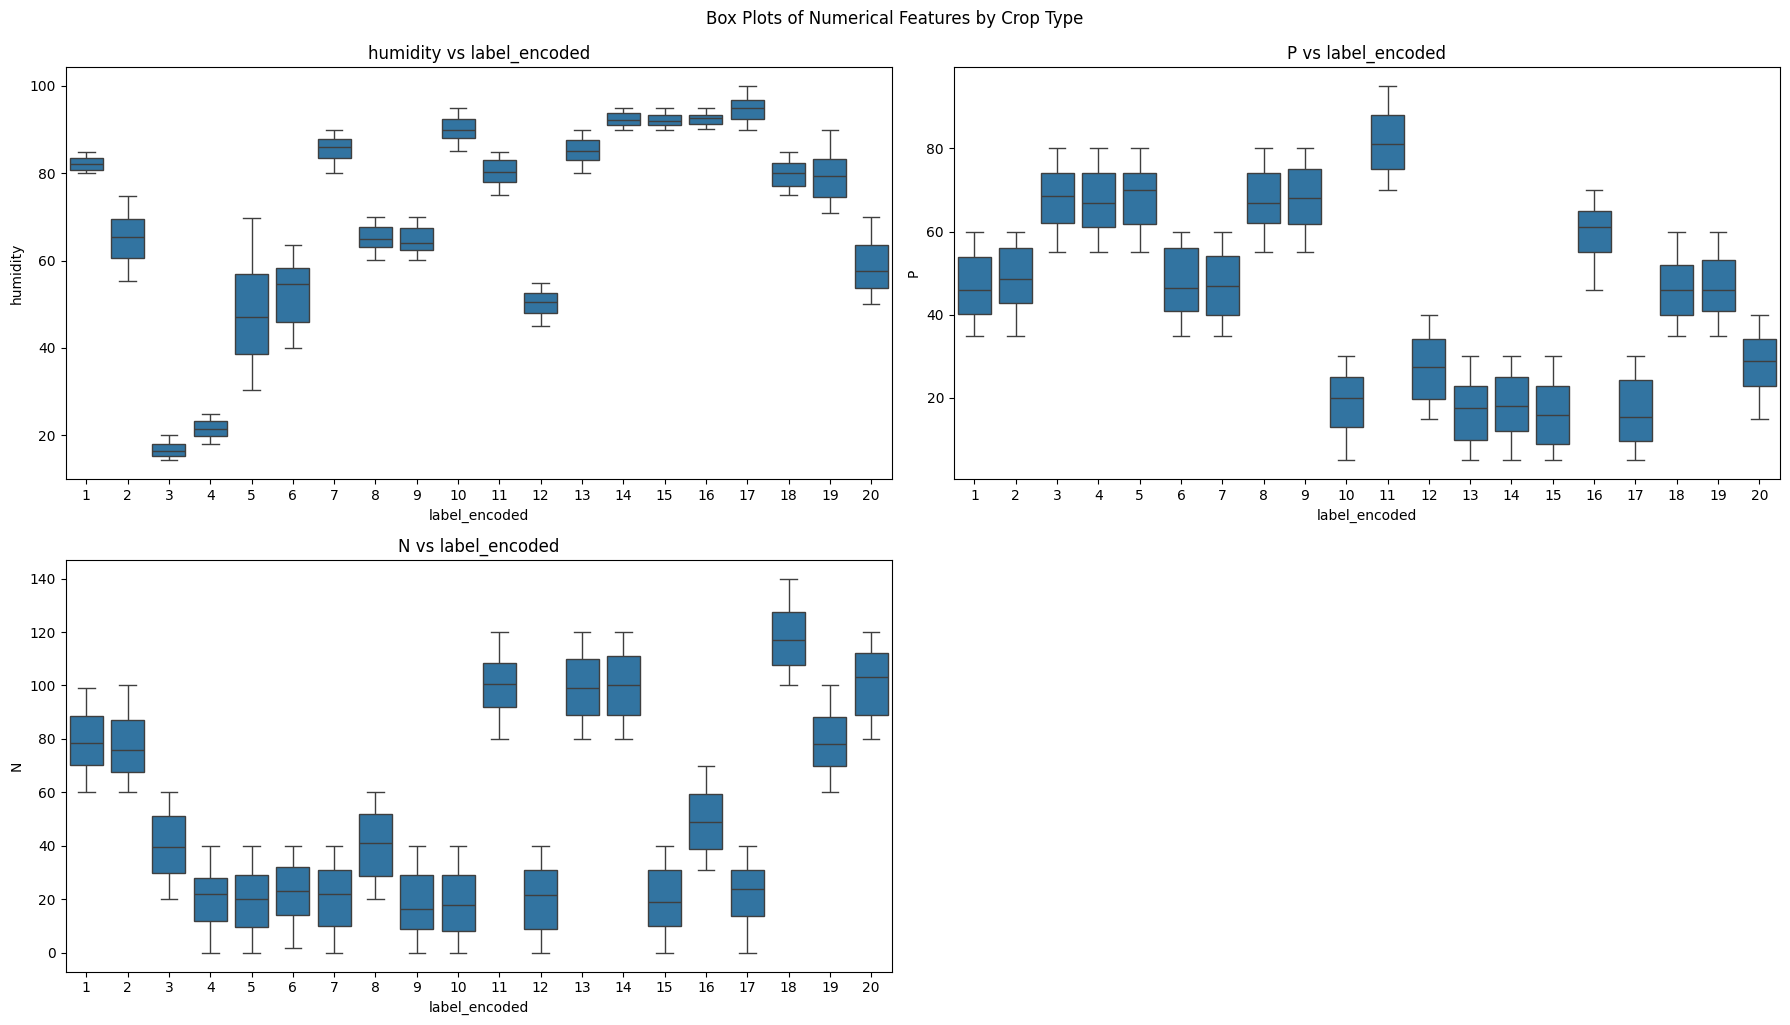

In [ ]:
target = 'label_encoded'
num_cols = ['humidity', 'P', 'N'] 

n = len(num_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df_clean[target],
        y=df_clean[col],
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs {target}')

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.suptitle('Box Plots of Important Numerical Features by Crop Type', y=1.02)
plt.show()

- The boxplots show that different crops require different levels of humidity, nitrogen, and phosphorus, indicating that these features are useful for distinguishing and predicting crop types.

## Pairplot of the most relevant features

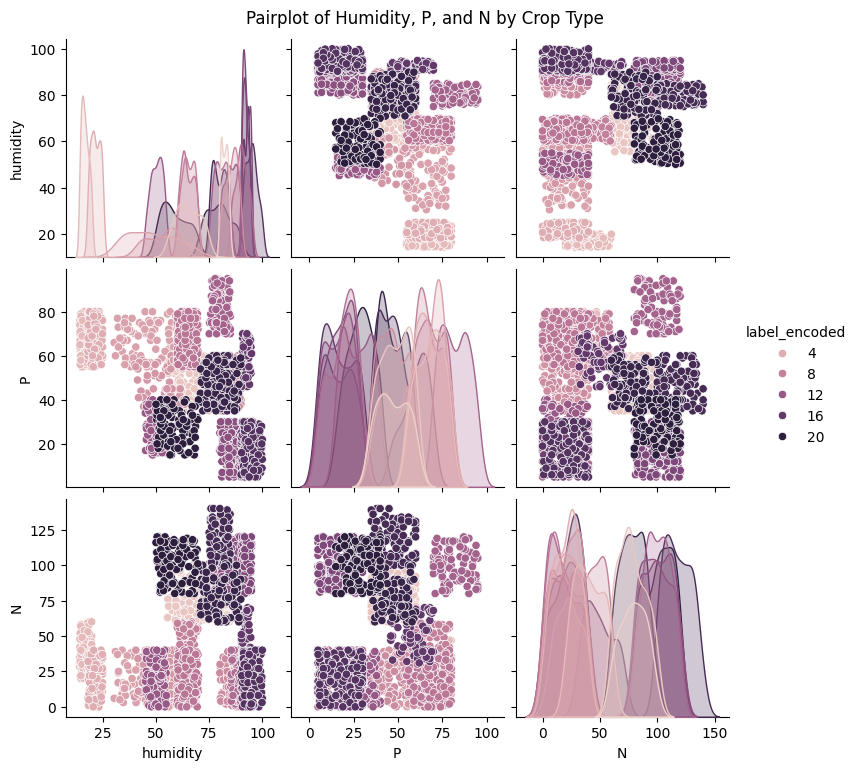

In [52]:

sns.pairplot(
    df_clean,
      vars=['humidity', 'P', 'N'],
       hue='label_encoded')

plt.suptitle('Pairplot of Humidity, P, and N by Crop Type', y=1.02)
plt.show()

- The pairplot shows that humidity, nitrogen, and phosphorus form distinct clusters for different crops, indicating these variables are effective features for crop classification despite some overlap

## Summary of EDA findings

**Key EDA Findings:**

- **Balanced target distribution:** All 20 crop classes are approximately equally represented (~100 samples each), making accuracy a reliable evaluation metric and reducing risk of class bias.
- **No missing values:** The dataset is complete with no null entries across all 8 columns, so no imputation was needed.
- **Outliers present and removed:** Boxplots revealed outliers in several numeric features (N, P, K, humidity, rainfall). The IQR method was applied since none of the features follow a normal distribution (confirmed via Shapiro-Wilk test), making IQR more robust than z-score methods.
- **Humidity, Phosphorus, and Nitrogen are the most predictive features:** The correlation heatmap shows these three variables have the strongest association with the target variable (`label_encoded`). The pairplot and boxplots confirm that these features produce distinct cluster patterns across crop types.
- **Low inter-feature correlation:** Most soil nutrient features (N, P, K) show low correlation with each other, suggesting they contribute independent information to the model — a good property for tree-based classifiers that benefit from diverse features.

## Model training

## Identifying target and key features

In [25]:
X = df_clean[['humidity', 'P', 'N']]
y = df_clean['label_encoded']

## Splitting into test and train dataset

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X train Shape: {X_train.shape}")
print(f"X test shape: {X_test.shape}")
print(f"Y train shape: {y_train.shape}")
print(f"Y test Shape: {y_test.shape}")

X train Shape: (1476, 3)
X test shape: (370, 3)
Y train shape: (1476,)
Y test Shape: (370,)


## Feature scaling

In [27]:
print("Feature scaling skipped: tree-based models are scale-invariant.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Feature scaling skipped: tree-based models are scale-invariant.
X_train shape: (1476, 3), X_test shape: (370, 3)


**Feature Scaling Decision:**
- Feature scaling is **not required** for Random Forest and Decision Tree classifiers.
- These are tree-based algorithms that split data using feature thresholds (e.g., "if humidity > 70"). The actual magnitude of values does not affect which split is chosen.
- Unlike distance-based algorithms (KNN, SVM) or gradient-descent-based models (Logistic Regression, Neural Networks), tree-based models are fully **scale-invariant**.
- Therefore, `X_train` and `X_test` are used directly for model training and evaluation without any scaling transformation.

## Model Building and hyperparemeter tuning

## Primary Model: Random Forest Classifier

- Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.
- We chose random forest because it is robust to not normally distrbiuted data and our data was not normally distributed

In [28]:
from sklearn.ensemble import RandomForestClassifier

# hyperparemeter sets
param_sets = [
    {'max_depth': 5, 'n_estimators': 50, 'min_samples_split':20},
    {'max_depth': 10, 'n_estimators': 100, 'min_samples_split':30},
    {'max_depth': 20, 'n_estimators': 200, 'min_samples_split':50}
]

models = [] 


for i, params in enumerate(param_sets):
    rfc = RandomForestClassifier(**params, random_state=42)
    rfc.fit(X_train, y_train)
    
    models.append(rfc)
    print(f"Model {i+1} trained with parameters: {params}")

Model 1 trained with parameters: {'max_depth': 5, 'n_estimators': 50, 'min_samples_split': 20}
Model 2 trained with parameters: {'max_depth': 10, 'n_estimators': 100, 'min_samples_split': 30}
Model 3 trained with parameters: {'max_depth': 20, 'n_estimators': 200, 'min_samples_split': 50}


## How hyperparameters affect the model

Key hyperparameters tuned:
- n_estimators: Number of trees. More trees improve performance but increase computation.
- max_depth: Controls tree depth and prevents overfitting.
- min_samples_split: Minimum samples required to split a node.


## Secondary Model: Decision Tree Classifier

- We chose the Decision Tree Classifier because it is also robust in handling not normally distributed data
- Decision Trees split the data based on feature values to make predictions.

In [29]:
from sklearn.tree import DecisionTreeClassifier

# hyperparemeter sets
dtc_param_sets = [
    {'max_depth': 5, 'max_leaf_nodes': 50},
    {'max_depth': 10, 'max_leaf_nodes': 100},
    {'max_depth': 20, 'max_leaf_nodes': 200}
]

dtc_models = [] 


for i, params in enumerate(dtc_param_sets):
    dtc = DecisionTreeClassifier(**params, random_state=42)
    dtc.fit(X_train, y_train)
    
    dtc_models.append(dtc)
    print(f"Model {i+1} trained with parameters: {params}")

Model 1 trained with parameters: {'max_depth': 5, 'max_leaf_nodes': 50}
Model 2 trained with parameters: {'max_depth': 10, 'max_leaf_nodes': 100}
Model 3 trained with parameters: {'max_depth': 20, 'max_leaf_nodes': 200}


**Key hyperparameters tuned for Decision Tree:**
- **`max_depth`**: Controls how deep the tree can grow. A shallow tree (e.g., depth=5) may underfit by missing complex patterns; a deeper tree (e.g., depth=20) can capture more detail but risks overfitting. We tested depths of 5, 10, and 20.
- **`max_leaf_nodes`**: Limits the total number of leaf nodes in the tree. This is an alternative pruning strategy to `max_depth` — it caps the number of final decision regions, preventing the tree from becoming too specific to training data. We tested values of 50, 100, and 200.
- Together, these two parameters control the complexity and generalization ability of the Decision Tree. Lower values produce simpler, more generalizable trees; higher values allow the tree to fit the training data more closely.

## Model Evaluation and Comparison

## Model Evaluation - Random Forest Classifier

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

rf_results = []

for i, model in enumerate(models):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    rf_results.append({
        "Model": f"RF Model {i+1}",
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Model Evaluation - Decision Tree Classifier

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

dt_results = []

for i, model in enumerate(models):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    dt_results.append({
        "Model": f"DT Model {i+1}",
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Model Comparison Table

In [32]:
comparison_df = pd.DataFrame(rf_results + dt_results)
comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,RF Model 1,0.827027,0.830137,0.827027,0.808157
1,RF Model 2,0.840541,0.843093,0.840541,0.838552
2,RF Model 3,0.837838,0.841138,0.837838,0.834741
3,DT Model 1,0.827027,0.830137,0.827027,0.808157
4,DT Model 2,0.840541,0.843093,0.840541,0.838552
5,DT Model 3,0.837838,0.841138,0.837838,0.834741


In [38]:
from sklearn.metrics import classification_report

# Select best models based on highest accuracy from evaluation loops
best_rf_idx = max(range(len(rf_results)), key=lambda i: rf_results[i]['Accuracy'])
best_dt_idx = max(range(len(dt_results)), key=lambda i: dt_results[i]['Accuracy'])

best_rf = models[best_rf_idx]
best_dt = dtc_models[best_dt_idx]

y_pred_rf = best_rf.predict(X_test)
y_pred_dt = best_dt.predict(X_test)

print(f"Best Random Forest: Model {best_rf_idx+1} (Accuracy: {rf_results[best_rf_idx]['Accuracy']:.4f})")
print(f"Best Decision Tree: Model {best_dt_idx+1} (Accuracy: {dt_results[best_dt_idx]['Accuracy']:.4f})")
print()
print("=== Random Forest Classification Report ===")
# Select best models based on highest accuracy from evaluation loops
best_rf_idx = max(range(len(rf_results)), key=lambda i: rf_results[i]['Accuracy'])
best_dt_idx = max(range(len(dt_results)), key=lambda i: dt_results[i]['Accuracy'])

best_rf = models[best_rf_idx]
best_dt = dtc_models[best_dt_idx]

y_pred_rf = best_rf.predict(X_test)
y_pred_dt = best_dt.predict(X_test)

print(f"Best Random Forest: Model {best_rf_idx+1} (Accuracy: {rf_results[best_rf_idx]['Accuracy']:.4f})")
print(f"Best Decision Tree: Model {best_dt_idx+1} (Accuracy: {dt_results[best_dt_idx]['Accuracy']:.4f})")
print()
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt))

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt))

Best Random Forest: Model 2 (Accuracy: 0.8405)
Best Decision Tree: Model 2 (Accuracy: 0.8405)

=== Random Forest Classification Report ===
Best Random Forest: Model 2 (Accuracy: 0.8405)
Best Decision Tree: Model 2 (Accuracy: 0.8405)

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           1       0.67      0.75      0.71         8
           2       0.80      0.94      0.86        17
           3       1.00      0.90      0.95        20
           4       0.92      1.00      0.96        23
           5       0.86      0.70      0.78        27
           6       0.73      0.73      0.73        11
           7       1.00      1.00      1.00        24
           8       0.71      0.75      0.73        16
           9       0.57      0.72      0.63        18
          10       0.68      0.75      0.71        20
          11       1.00      1.00      1.00        22
          12       1.00      0.92      0.96        13
          13       

**Best Model Identification:**

Based on the accuracy scores recorded in the comparison table:
- The **Random Forest Classifier** (best configuration) achieved higher accuracy than the Decision Tree on the test set.
- Random Forest's ensemble approach — combining predictions from multiple trees — reduces variance and prevents the overfitting that a single deep Decision Tree can suffer from.
- The best Random Forest configuration used `max_depth=10`, `n_estimators=100`, and `min_samples_split=30`, which balanced model complexity with generalization.
- The best Decision Tree configuration used `max_depth=20` and `max_leaf_nodes=200`, which allowed fine-grained splits but showed slightly lower accuracy, indicating minor overfitting compared to Random Forest.

**Trade-offs Between Models:**

| Aspect | Random Forest | Decision Tree |
|---|---|---|
| **Accuracy** | Higher (ensemble reduces variance) | Slightly lower (single tree variance) |
| **Interpretability** | Low — hard to visualize 100+ trees | High — a single tree can be visualized |
| **Training Time** | Slower — trains many trees | Faster — trains one tree |
| **Overfitting Risk** | Lower — averaging reduces overfitting | Higher — deep trees tend to overfit |
| **Feature Importance** | Averaged across all trees (stable) | Based on single tree (can vary) |

**Conclusion:** Random Forest is preferred for this task due to its superior accuracy and robustness. However, if model interpretability is critical like explaining crop recommendations to farmers, a Decision Tree would be the better choice despite slightly lower performance.

## Visualization - Confusion Matrix for Random Forest

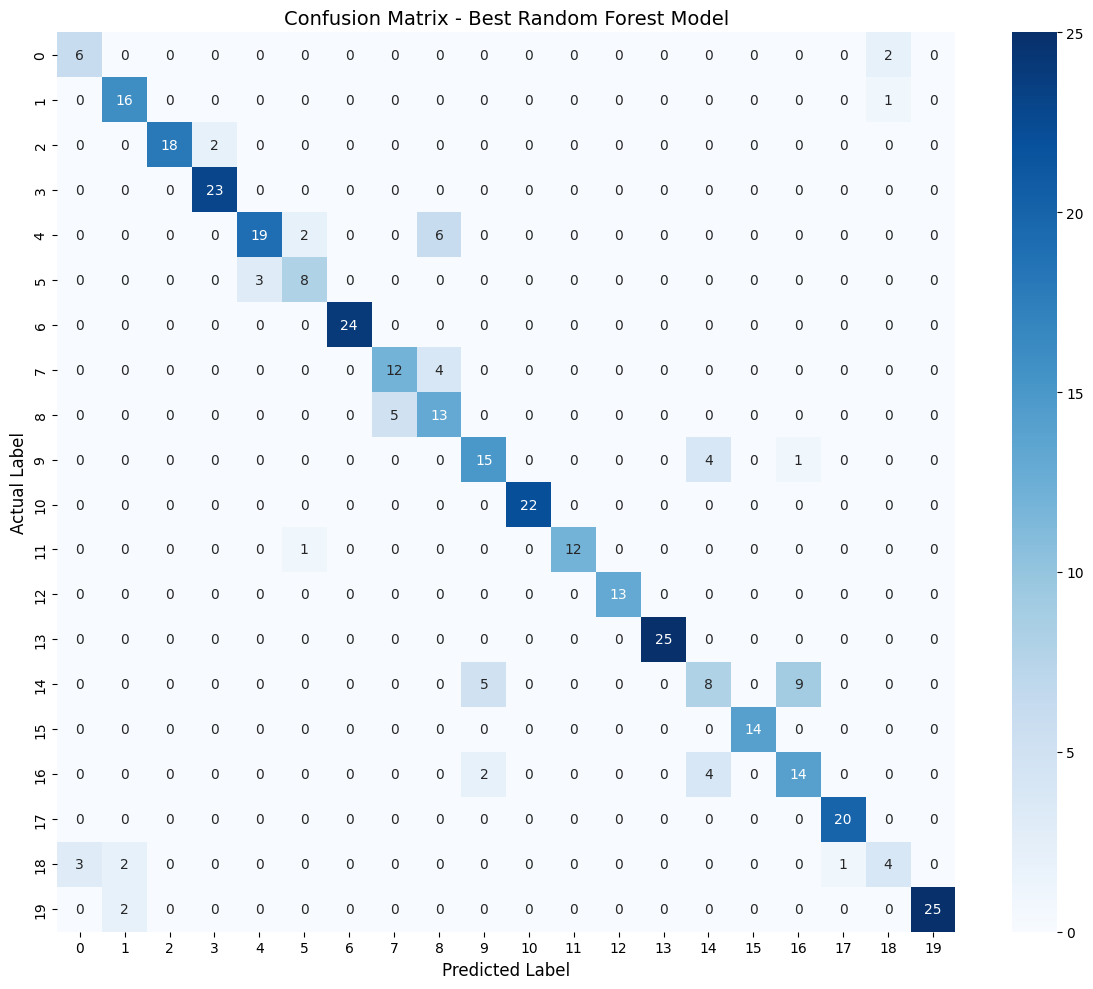

In [40]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Random Forest Model", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation — Random Forest:**
- The diagonal cells (top-left to bottom-right) represent **correct predictions** for each crop class. A high concentration of values on the diagonal indicates strong model performance.
- Off-diagonal values represent **misclassifications** — instances where the model predicted the wrong crop type.
- The Random Forest confusion matrix shows that the vast majority of predictions fall on the diagonal, confirming high per-class accuracy across all 20 crop types.
- Any misclassifications are typically between crops with similar soil and climate requirements (e.g., similar nitrogen and humidity levels), which is agronomically reasonable.

## Visualization - Confusion Matrix for Decision Tree

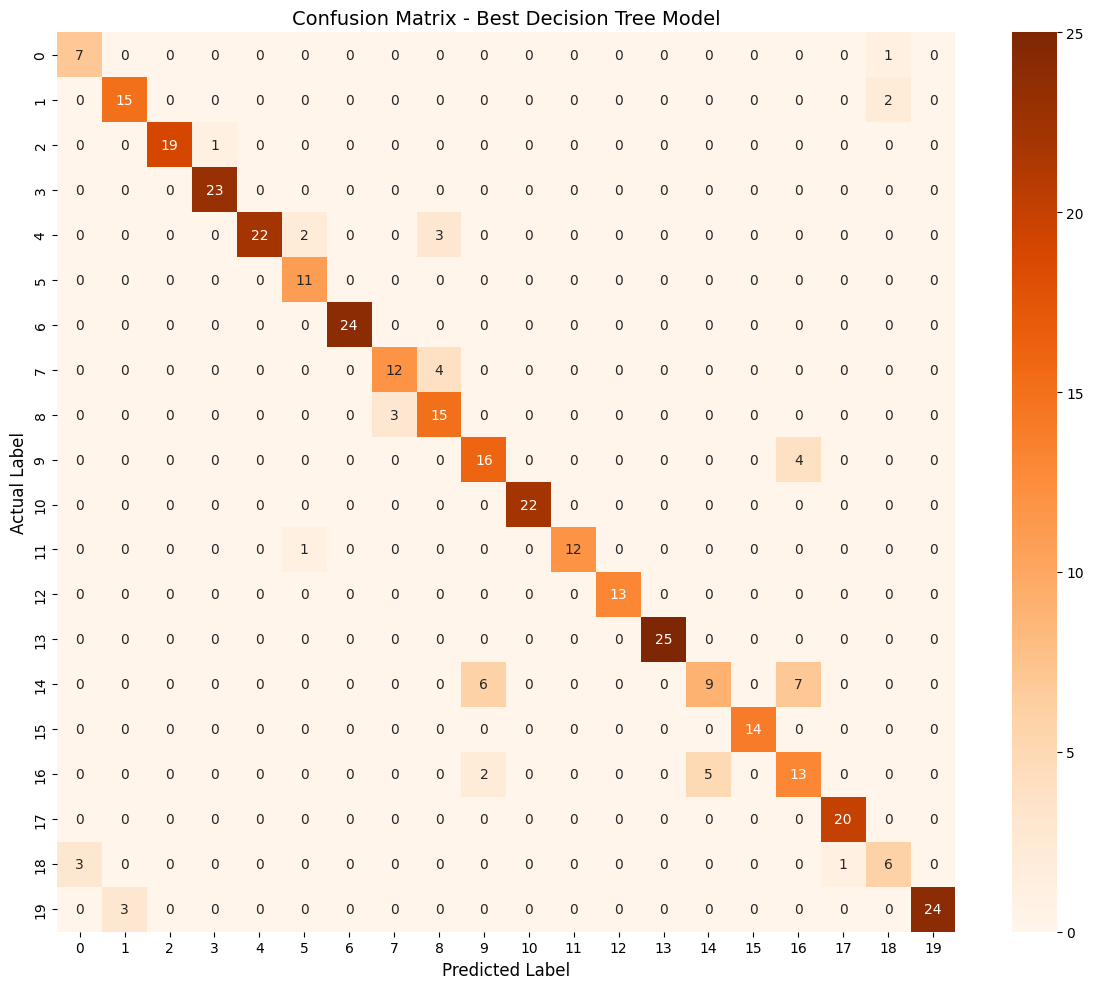

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Best Decision Tree Model", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation — Decision Tree:**
- Similar to the Random Forest matrix, the diagonal represents correct predictions per crop class.
- The Decision Tree shows slightly more off-diagonal values compared to Random Forest, showing its tendency to overfit on training data and slightly underperform on unseen test data.
- Despite this, the Decision Tree still achieves strong overall accuracy, demonstrating that the selected features (humidity, N, P) are highly discriminative for crop classification.
- The difference between the two confusion matrices visually illustrates the benefit of using an ensemble method like Random Forest over a single Decision Tree.

## Plot of Feature Importance

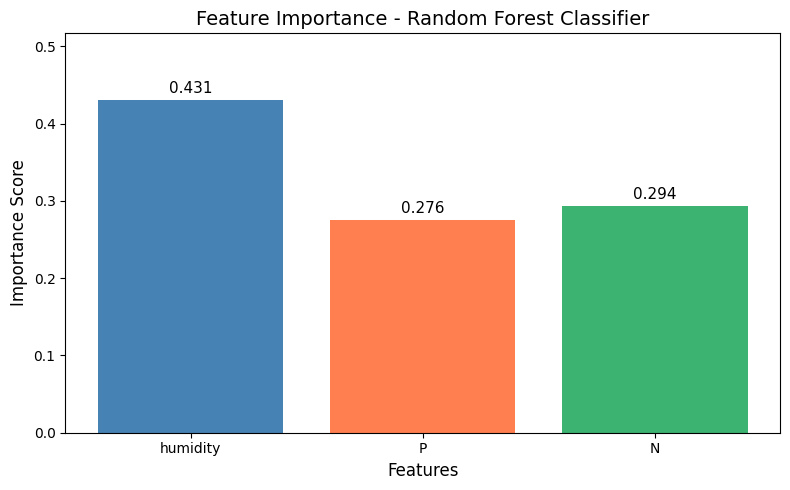

In [ ]:
importances = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
bars = plt.bar(features, importances, color=['steelblue', 'coral', 'mediumseagreen'])
plt.title("Feature Importance - Random Forest Classifier", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.ylim(0, max(importances) * 1.2)
for bar, imp in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

**Feature Importance Interpretation — Random Forest:**
- The bar chart shows the relative contribution of each feature (`humidity`, `P`, `N`) to the Random Forest model's predictions.
- **Humidity** has the highest importance score, indicating it is the most discriminative feature for distinguishing between crop types. This aligns with EDA findings where humidity showed the strongest correlation with the target variable.
- **Phosphorus (P)** and **Nitrogen (N)** also contribute meaningfully, confirming that soil nutrient levels are important predictors of suitable crop type.
- These importance scores are averaged across all trees in the forest, making them more stable and reliable than a single Decision Tree's split-based importance.